# Resumen del Módulo 1: Introducción al Análisis de Datos

Este cuaderno resume los conceptos más importantes del módulo 1:
- ¿Qué es el análisis de datos?
- ¿Por qué es importante?
- Cómo explorar, resumir y visualizar datos básicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [8]:
print("Versiones de las librerías:")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {mpl.__version__}")

Versiones de las librerías:
Pandas: 3.0.1
Numpy: 2.4.3
Matplotlib: 3.11.0


In [10]:
datos = pd.DataFrame({
    'Edad': [18, 22, 25, 30, 35, 40],
    'Horas_estudio': [2, 4, 5, 6, 7, 8],
    'Calificacion': [70, 75, 80, 85, 88, 92]
})
datos.head()

,Edad,Horas_estudio,Calificacion
0,18,2,70
1,22,4,75
2,25,5,80
3,30,6,85
4,35,7,88


In [11]:
datos.info()
datos.isnull().sum()
datos.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Edad           6 non-null      int64
 1   Horas_estudio  6 non-null      int64
 2   Calificacion   6 non-null      int64
dtypes: int64(3)
memory usage: 276.0 bytes


,Edad,Horas_estudio,Calificacion
count,6.000000,6.000000,6.000000
mean,28.333333,5.333333,81.666667
std,8.262364,2.160247,8.262364
min,18.000000,2.000000,70.000000
25%,22.750000,4.250000,76.250000
50%,27.500000,5.500000,82.500000
75%,33.750000,6.750000,87.250000
max,40.000000,8.000000,92.000000


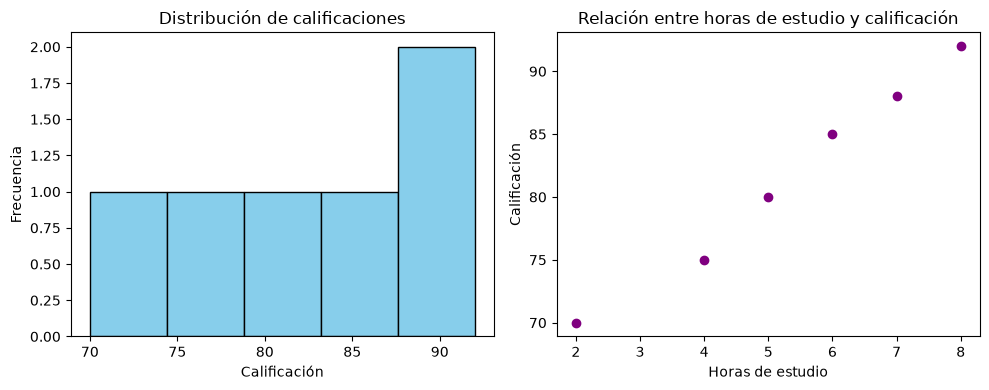

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(datos['Calificacion'], bins=5, color='skyblue', edgecolor='black')
plt.title('Distribución de calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.scatter(datos['Horas_estudio'], datos['Calificacion'], color='purple')
plt.title('Relación entre horas de estudio y calificación')
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación')
plt.tight_layout()
plt.show()

## Resumen de conceptos clave

1. Cargar datos y explorar su estructura.
2. Revisar tipos de variables y valores faltantes.
3. Calcular estadísticas descriptivas básicas.
4. Visualizar patrones para interpretar la información.

## Pandas: ejemplos prácticos para clase

Esta sección amplía el resumen con ejercicios sencillos sobre:
- creación y exploración de DataFrames
- selección, slicing y filtrado
- manejo de valores faltantes
- agrupación y agregación
- unión de tablas

> En la práctica, los temas de estas preguntas se cubren con ejemplos cortos y reproducibles.

## Ejemplo 1: crear y explorar un DataFrame

```python
import pandas as pd

ventas = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor'],
    'Region': ['Norte', 'Sur', 'Norte', 'Sur'],
    'Ventas': [1200, 450, 700, 900]
})

print(ventas)
print('\nDimensiones:', ventas.shape)
print('\nTipos de datos:\n', ventas.dtypes)
print('\nResumen:\n', ventas.describe())
```


In [2]:
import pandas as pd

ventas = pd.DataFrame({
    'Producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor'],
    'Region': ['Norte', 'Sur', 'Norte', 'Sur'],
    'Ventas': [1200, 450, 700, 900]
})

print(ventas)
print('\nDimensiones:', ventas.shape)
print('\nTipos de datos:\n', ventas.dtypes)
print('\nResumen:\n', ventas.describe())

  Producto Region  Ventas
0   Laptop  Norte    1200
1    Mouse    Sur     450
2  Teclado  Norte     700
3  Monitor    Sur     900

Dimensiones: (4, 3)

Tipos de datos:
 Producto      str
Region        str
Ventas      int64
dtype: object

Resumen:
             Ventas
count     4.000000
mean    812.500000
std     317.214439
min     450.000000
25%     637.500000
50%     800.000000
75%     975.000000
max    1200.000000


## Ejemplo 2: selección, slicing y filtrado

```python
# una columna
print('Ventas:', ventas['Ventas'].sum())

# varias columnas
print('\nProducto y Región:\n', ventas[['Producto', 'Region']])

# primeras filas
print('\nPrimeras 3 filas:\n', ventas.head(3))

# fila por posición
print('\nFila 1 por iloc:', ventas.iloc[1].to_dict())

# filtrado
print('\nVentas > 500:\n', ventas[ventas['Ventas'] > 500])
```


In [3]:
# una columna
print('Ventas:', ventas['Ventas'].sum())

# varias columnas
print('\nProducto y Región:\n', ventas[['Producto', 'Region']])

# primeras filas
print('\nPrimeras 3 filas:\n', ventas.head(3))

# fila por posición
print('\nFila 1 por iloc:', ventas.iloc[1].to_dict())

# filtrado
print('\nVentas > 500:\n', ventas[ventas['Ventas'] > 500])

Ventas: 3250

Producto y Región:
   Producto Region
0   Laptop  Norte
1    Mouse    Sur
2  Teclado  Norte
3  Monitor    Sur

Primeras 3 filas:
   Producto Region  Ventas
0   Laptop  Norte    1200
1    Mouse    Sur     450
2  Teclado  Norte     700

Fila 1 por iloc: {'Producto': 'Mouse', 'Region': 'Sur', 'Ventas': 450}

Ventas > 500:
   Producto Region  Ventas
0   Laptop  Norte    1200
2  Teclado  Norte     700
3  Monitor    Sur     900


## Diferencia entre `at` / `iat` y `loc` / `iloc`

| Método | Base | Qué devuelve | ¿Permite rangos o varios elementos? | Ejemplo típico |
|---|---|---|---|---|
| `at` | etiquetas (label-based) | una sola celda | No | `df.at[0, 'Producto']` |
| `iat` | posición entera | una sola celda | No | `df.iat[0, 0]` |
| `loc` | etiquetas | una fila, una columna, o un subconjunto | Sí | `df.loc[0:2, ['Producto', 'Ventas']]` |
| `iloc` | posición entera | una fila, una columna, o un subconjunto | Sí | `df.iloc[0:2, 0:2]` |

### Idea clave
- `at` / `iat` están pensados para acceso muy rápido a un único valor.
- `loc` / `iloc` son más flexibles y sirven para filtrar, cortar y seleccionar porciones del DataFrame.

En pandas 3.0.1, `at` y `iat` siguen existiendo; la diferencia principal no es de “deprecación”, sino de alcance y velocidad.

In [14]:
ventas.at[0, 'Producto'] = 'Portátil'
print(ventas)

   Producto Region  Ventas
0  Portátil  Norte    1200
1     Mouse    Sur     450
2   Teclado  Norte     700
3   Monitor    Sur     900


In [15]:
ventas.iat[0, 0]

'Portátil'

## Ejemplo 3: valores faltantes y limpieza

```python
clientes = pd.DataFrame({
    'Cliente': ['Ana', 'Luis', 'Mara'],
    'Edad': [25, None, 30],
    'Compra': [100, 200, None]
})

print('Datos originales:\n', clientes)
print('\nNulos por columna:\n', clientes.isnull().sum())

clientes_limpios = clientes.fillna({'Edad': clientes['Edad'].mean(), 'Compra': 0})
print('\nDespués de fillna:\n', clientes_limpios)
```


In [4]:
clientes = pd.DataFrame({
    'Cliente': ['Ana', 'Luis', 'Mara'],
    'Edad': [25, None, 30],
    'Compra': [100, 200, None]
})

print('Datos originales:\n', clientes)
print('\nNulos por columna:\n', clientes.isnull().sum())

clientes_limpios = clientes.fillna({'Edad': clientes['Edad'].mean(), 'Compra': 0})
print('\nDespués de fillna:\n', clientes_limpios)

Datos originales:
   Cliente  Edad  Compra
0     Ana  25.0   100.0
1    Luis   NaN   200.0
2    Mara  30.0     NaN

Nulos por columna:
 Cliente    0
Edad       1
Compra     1
dtype: int64

Después de fillna:
   Cliente  Edad  Compra
0     Ana  25.0   100.0
1    Luis  27.5   200.0
2    Mara  30.0     0.0


## Ejemplo 4: agrupación y agregación

```python
ventas_region = ventas.groupby('Region')['Ventas'].sum().reset_index()
print('Ventas por región:\n', ventas_region)

promedio_region = ventas.groupby('Region')['Ventas'].mean().reset_index()
print('\nPromedio por región:\n', promedio_region)
```


In [5]:
ventas_region = ventas.groupby('Region')['Ventas'].sum().reset_index()
print('Ventas por región:\n', ventas_region)

promedio_region = ventas.groupby('Region')['Ventas'].mean().reset_index()
print('\nPromedio por región:\n', promedio_region)

Ventas por región:
   Region  Ventas
0  Norte    1900
1    Sur    1350

Promedio por región:
   Region  Ventas
0  Norte   950.0
1    Sur   675.0


## Ejemplo 5: merge y concat

```python
clientes = pd.DataFrame({
    'id': [1, 2, 3],
    'Cliente': ['Ana', 'Luis', 'Mara']
})

compras = pd.DataFrame({
    'id': [1, 2, 4],
    'Compra': [100, 200, 300]
})

unido = pd.merge(clientes, compras, on='id', how='inner')
print('Merge:\n', unido)

apilado = pd.concat([clientes[['Cliente']], compras[['Compra']]], axis=1)
print('\nConcat (por posición):\n', apilado)
```


In [6]:
clientes = pd.DataFrame({
    'id': [1, 2, 3],
    'Cliente': ['Ana', 'Luis', 'Mara']
})

compras = pd.DataFrame({
    'id': [1, 2, 4],
    'Compra': [100, 200, 300]
})

unido = pd.merge(clientes, compras, on='id', how='inner')
print('Merge:\n', unido)

apilado = pd.concat([clientes[['Cliente']], compras[['Compra']]], axis=1)
print('\nConcat (por posición):\n', apilado)

Merge:
    id Cliente  Compra
0   1     Ana     100
1   2    Luis     200

Concat (por posición):
   Cliente  Compra
0     Ana     100
1    Luis     200
2    Mara     300


## Ejemplo 6: orden, query y pivot

```python
ventas_orden = ventas.sort_values('Ventas', ascending=False)
print('Orden descendente:\n', ventas_orden[['Producto', 'Ventas']])

filtro = ventas.query('Region == "Norte" and Ventas > 500')
print('\nQuery:\n', filtro)

pivot = ventas.pivot_table(index='Region', values='Ventas', aggfunc='sum')
print('\nPivot tabla:\n', pivot)
```


In [7]:
ventas_orden = ventas.sort_values('Ventas', ascending=False)
print('Orden descendente:\n', ventas_orden[['Producto', 'Ventas']])

filtro = ventas.query('Region == "Norte" and Ventas > 500')
print('\nQuery:\n', filtro)

pivot = ventas.pivot_table(index='Region', values='Ventas', aggfunc='sum')
print('\nPivot tabla:\n', pivot)

Orden descendente:
   Producto  Ventas
0   Laptop    1200
3  Monitor     900
2  Teclado     700
1    Mouse     450

Query:
   Producto Region  Ventas
0   Laptop  Norte    1200
2  Teclado  Norte     700

Pivot tabla:
         Ventas
Region        
Norte     1900
Sur       1350


## Ejemplo 7: mini ejercicio de repaso

```python
# Identificar el producto más vendido por región
producto_por_region = (
    ventas.sort_values(['Region', 'Ventas'], ascending=[True, False])
    .groupby('Region', as_index=False)
    .first()
)

print(producto_por_region[['Region', 'Producto', 'Ventas']])
```


In [8]:
# Identificar el producto más vendido por región
producto_por_region = (
    ventas.sort_values(['Region', 'Ventas'], ascending=[True, False])
    .groupby('Region', as_index=False)
    .first()
)

print(producto_por_region[['Region', 'Producto', 'Ventas']])

  Region Producto  Ventas
0  Norte   Laptop    1200
1    Sur  Monitor     900
